# 08 — CGM Daily Means × Study Group Stratification

**Purpose**: Characterise how mean glucose varies across the four diabetes severity groups
(Healthy, Pre-DM, Oral Med, Insulin) and test whether the dose-response gradient is
statistically significant.

**Inputs** (from notebook 07):  
- `data/processed/features_with_cluster.csv`  
- `data/processed/cgm_aggregated.csv`

**Output**: `data/processed/08_study_group_summary.csv`


In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['azure-storage-blob', 'plotly', 'scipy', 'scikit-learn', 'seaborn']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
CLUSTER_MAP       = {0: 'Cardiometabolic', 1: 'Musculoskeletal-Inflammatory'}

# ── Mount Google Drive (persistent across independent kernels) ────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print('Environment ready. Output dir:', out_dir)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Environment ready. Output dir: /content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs


In [3]:
# ── 2. Load Feature Files (outputs from notebook 07) ─────────────────────
features = pd.read_csv(out_dir / 'features_with_cluster.csv')
cgm      = pd.read_csv(out_dir / 'cgm_aggregated.csv')

# Ensure study_group_label ordering

# Derive study_group_label from code if missing (e.g. stale CSV from nb07)
if 'study_group_label' not in features.columns:
    features['study_group_label'] = features['study_group_code'].map(STUDY_GROUP_MAP)

if 'study_group_label' not in cgm.columns:
    cgm['study_group_label'] = cgm['study_group_code'].map(STUDY_GROUP_MAP)
features['study_group_label'] = pd.Categorical(
    features['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)
cgm['study_group_label'] = pd.Categorical(
    cgm['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

print(f'features: {features.shape}   cgm: {cgm.shape}')
print('Columns:', features.columns.tolist())


features: (2245, 22)   cgm: (2245, 9)
Columns: ['person_id', 'mean_glucose', 'comorbidity_cluster', 'comorbidity_index', 'study_group_code', 'cesd_total', 'paid_total', 'dml_gap_physical_activity', 'dml_gap_diet_adherence', 'dml_gap_education', 'dml_gap_foot_care', 'dml_gap_medication_mgmt', 'dml_gap_composite', 'discrimination_score', 'healthcare_access_barriers', 'food_housing_insecurity', 'neighborhood_safety_score', 'substance_exposure_count', 'otc_burden_count', 'family_risk_level', 'site_code', 'study_group_label']


In [4]:
def spearman_table(df, target='mean_glucose'):
    """Return ranked Spearman rho table for all numeric predictors vs target."""
    num_cols = df.select_dtypes(include='number').columns.tolist()
    preds    = [c for c in num_cols if c not in (target, 'person_id')]
    rows = {}
    for col in preds:
        sub = df[[target, col]].dropna()
        if len(sub) > 30:
            rho, p = stats.spearmanr(sub[target], sub[col])
            rows[col] = {'rho': round(rho,4), 'p': round(p,5), 'n': len(sub)}
    return pd.DataFrame(rows).T.sort_values('rho', key=abs, ascending=False)


## 3. Distribution Analysis

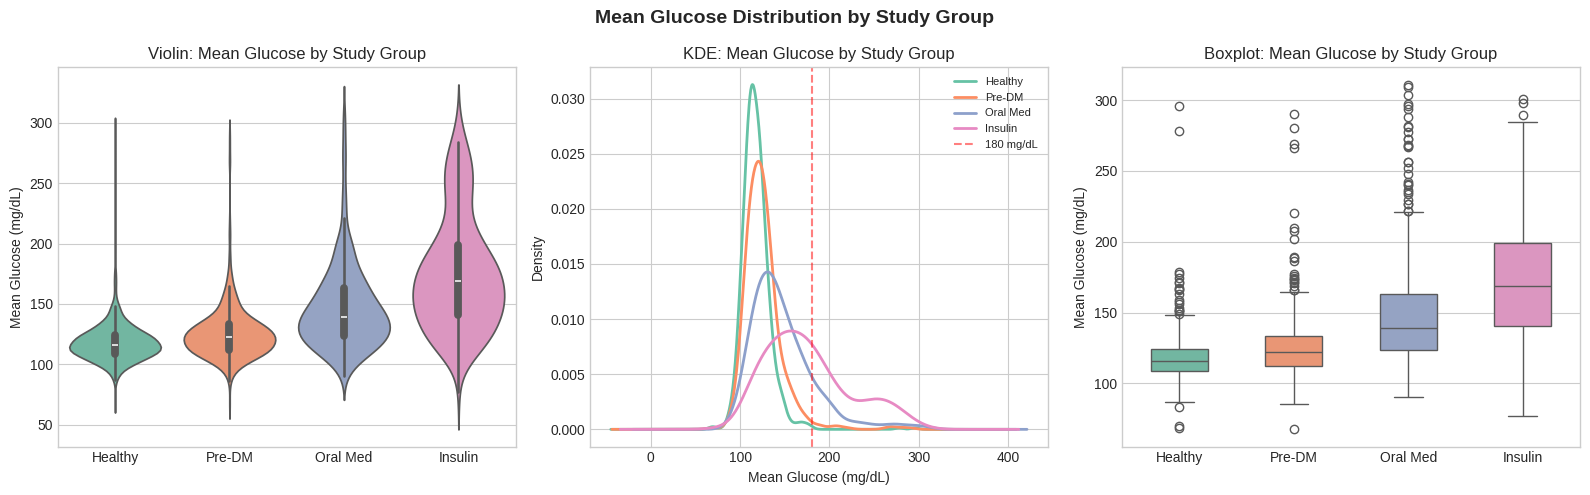

In [5]:
# ── 3a. Violin + KDE + Boxplot ───────────────────────────────────────────
df_plot = features.dropna(subset=['study_group_label', 'mean_glucose']).copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Mean Glucose Distribution by Study Group', fontsize=14, fontweight='bold')

sns.violinplot(data=df_plot, x='study_group_label', y='mean_glucose',
               order=STUDY_GROUP_ORDER, palette='Set2', inner='box', ax=axes[0])
axes[0].set_title('Violin: Mean Glucose by Study Group')
axes[0].set_xlabel('')
axes[0].set_ylabel('Mean Glucose (mg/dL)')

for grp in STUDY_GROUP_ORDER:
    subset = df_plot[df_plot['study_group_label'] == grp]['mean_glucose'].dropna()
    subset.plot.kde(ax=axes[1], label=grp, linewidth=2)
axes[1].axvline(180, color='red', linestyle='--', alpha=0.5, label='180 mg/dL')
axes[1].set_title('KDE: Mean Glucose by Study Group')
axes[1].set_xlabel('Mean Glucose (mg/dL)')
axes[1].legend(fontsize=8)

sns.boxplot(data=df_plot, x='study_group_label', y='mean_glucose',
            order=STUDY_GROUP_ORDER, palette='Set2', width=0.5, ax=axes[2])
axes[2].set_title('Boxplot: Mean Glucose by Study Group')
axes[2].set_xlabel('')
axes[2].set_ylabel('Mean Glucose (mg/dL)')

plt.tight_layout()
plt.show()


## 4. Statistical Tests

In [6]:
# ── 4a. Kruskal-Wallis omnibus ───────────────────────────────────────────
groups = [df_plot[df_plot['study_group_label'] == g]['mean_glucose'].dropna().values
          for g in STUDY_GROUP_ORDER]

stat, p_kw = stats.kruskal(*groups)
print(f'Kruskal-Wallis H={stat:.3f}  p={p_kw:.2e}')


Kruskal-Wallis H=666.600  p=3.67e-144


In [7]:
# ── 4b. Post-hoc Dunn test (manual pairwise Mann-Whitney + Bonferroni) ───
from itertools import combinations

pairs = list(combinations(STUDY_GROUP_ORDER, 2))
bonferroni_alpha = 0.05 / len(pairs)
print(f'Bonferroni-corrected alpha = {bonferroni_alpha:.4f}  ({len(pairs)} comparisons)\n')
print(f'{"Pair":<30}  {"U stat":>10}  {"p (raw)":>10}  {"sig?":>6}')
print('-' * 65)
for g1, g2 in pairs:
    a = df_plot[df_plot['study_group_label'] == g1]['mean_glucose'].dropna()
    b = df_plot[df_plot['study_group_label'] == g2]['mean_glucose'].dropna()
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    sig = '***' if p < bonferroni_alpha else ('*' if p < 0.05 else 'ns')
    print(f'{g1} vs {g2:<20}  {u:>10.0f}  {p:>10.4f}  {sig:>6}')


Bonferroni-corrected alpha = 0.0083  (6 comparisons)

Pair                                U stat     p (raw)    sig?
-----------------------------------------------------------------
Healthy vs Pre-DM                    158476      0.0000     ***
Healthy vs Oral Med                  102379      0.0000     ***
Healthy vs Insulin                    17882      0.0000     ***
Pre-DM vs Oral Med                  107911      0.0000     ***
Pre-DM vs Insulin                    20535      0.0000     ***
Oral Med vs Insulin                    52914      0.0000     ***


In [8]:
# ── 4c. Dose-response trend: Spearman on ordered codes ───────────────────
rho, p_trend = stats.spearmanr(df_plot['study_group_code'], df_plot['mean_glucose'])
print(f'Spearman trend test (study_group_code vs mean_glucose):')
print(f'  rho = {rho:.4f}   p = {p_trend:.2e}')


Spearman trend test (study_group_code vs mean_glucose):
  rho = 0.5379   p = 1.38e-168


## 5. Spearman Correlations (within each study group)

In [9]:
# ── 5. Ranked Spearman correlations per group ────────────────────────────
for grp in STUDY_GROUP_ORDER:
    sub = features[features['study_group_label'] == grp]
    ct  = spearman_table(sub)
    print(f'\n=== {grp} (n={len(sub):,}) — Top correlates with mean glucose ===')
    print(ct.head(8).to_string())



=== Healthy (n=761) — Top correlates with mean glucose ===
                            rho     p       n
substance_exposure_count -0.121 0.001 761.000
dml_gap_education        -0.111 0.002 761.000
paid_total                0.103 0.005 739.000
dml_gap_diet_adherence    0.099 0.006 761.000
otc_burden_count         -0.091 0.014 733.000
discrimination_score      0.089 0.014 761.000
food_housing_insecurity   0.083 0.022 761.000
site_code                 0.081 0.025 761.000

=== Pre-DM (n=552) — Top correlates with mean glucose ===
                             rho     p       n
dml_gap_physical_activity  0.122 0.004 552.000
site_code                  0.088 0.039 552.000
family_risk_level          0.072 0.091 552.000
comorbidity_index          0.071 0.093 552.000
substance_exposure_count  -0.066 0.122 552.000
dml_gap_diet_adherence     0.060 0.156 552.000
dml_gap_medication_mgmt   -0.058 0.172 552.000
paid_total                 0.056 0.196 543.000

=== Oral Med (n=681) — Top correlates with 

## 6. Summary Table & Export

In [10]:
# ── 6. Summary table ─────────────────────────────────────────────────────
summary = (
    df_plot.groupby('study_group_label', observed=True)['mean_glucose']
    .agg(n='count', mean='mean', std='std', median='median',
         q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75),
         pct_gt_180=lambda x: (x > 180).mean() * 100)
    .round(2)
    .reset_index()
)
summary.columns = ['Study Group', 'N', 'Mean (mg/dL)', 'SD', 'Median',
                   'Q25', 'Q75', '% > 180 mg/dL']
print(summary.to_string(index=False))

summary.to_csv(out_dir / '08_study_group_summary.csv', index=False)
print('\nSaved 08_study_group_summary.csv')


Study Group   N  Mean (mg/dL)     SD  Median     Q25     Q75  % > 180 mg/dL
    Healthy 761       117.990 16.330 115.730 108.660 124.540          0.260
     Pre-DM 552       125.860 22.360 122.420 112.080 133.560          1.990
   Oral Med 681       147.420 36.100 139.260 123.550 162.760         13.950
    Insulin 251       175.590 47.200 168.560 140.370 199.160         37.850

Saved 08_study_group_summary.csv


## 7. Key Findings

- **Omnibus test**: Kruskal-Wallis H = 666.6, p = 3.67e-144 — mean glucose differs highly significantly across the four study groups.
- **Dose-response**: Spearman rho = 0.538, p = 1.38e-168 — strong, monotonic increase from Healthy (117.99 mg/dL) → Pre-DM (125.86) → Oral Med (147.42) → Insulin (175.59 mg/dL).
- **Post-hoc**: All 6 pairwise comparisons are significant (p < 0.0001) after Bonferroni correction (α = 0.0083), including adjacent groups.
- **Threshold exceedance**: The proportion of daily means exceeding 180 mg/dL escalates dramatically across groups — Healthy 0.26%, Pre-DM 1.99%, Oral Med 13.95%, Insulin 37.85%.
- **Strongest within-group correlates with mean glucose**:
  - *Healthy* (n=761): `substance_exposure_count` (rho = −0.121), `dml_gap_education` (rho = −0.111), `paid_total` (rho = +0.103)
  - *Pre-DM* (n=552): `dml_gap_physical_activity` (rho = +0.122), `site_code` (rho = +0.088)
  - *Oral Med* (n=681): `food_housing_insecurity` (rho = −0.134), `paid_total` (rho = +0.084)
  - *Insulin* (n=251): `food_housing_insecurity` (rho = −0.159), `dml_gap_physical_activity` (rho = +0.148)
